## Introduction

This notebook investigates the prediction of students' final mathematics 
grades (G3) using the UCI Student Performance dataset. Three regression 
models are compared: Linear Regression, k-NN, and Decision Tree. G1 and 
G2 are excluded so that predictions rely only on demographic and social 
features. Models are evaluated using MAE and RMSE on a held-out test set.

## Methodology

The dataset contains 395 students and 33 variables. After removing G1 and 
G2, 30 input features remained. Seventeen categorical variables were 
one-hot encoded, expanding the feature matrix to 56 columns. No missing 
values were found. Data were split 80/20 into training and test sets 
(random_state=42). StandardScaler was applied only for k-NN, as it is 
distance-based. All other models used the encoded features directly.

In [235]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

## 1. Data Loading and Preparation

In [236]:
# Load the dataset
df = pd.read_csv("student-mat.csv", sep=";")

# Check the size and variable types
print("Shape of dataset:", df.shape)
print(df.dtypes)

# Define target and predictors
y = df["G3"]
X = df.drop(columns=["G3", "G1", "G2"])

# Check missing values
print("Missing values:", df.isnull().sum().sum())

Shape of dataset: (395, 33)
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object
Missing values: 0


In [237]:
# List of categorical variables given in the brief
categorical_cols = [
    "school", "sex", "address", "famsize", "Pstatus", "Mjob", "Fjob",
    "reason", "guardian", "schoolsup", "famsup", "paid", "activities",
    "nursery", "higher", "internet", "romantic"
]

# One-hot encode categorical variables
X_encoded = pd.get_dummies(X, columns=categorical_cols)

print("Shape before encoding:", X.shape)
print("Shape after encoding:", X_encoded.shape)

Shape before encoding: (395, 30)
Shape after encoding: (395, 56)


## 2. Exploratory Data Analysis

In [238]:
# Summary statistics for numeric variables
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


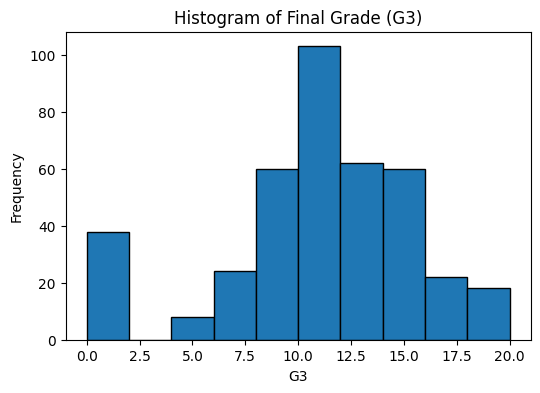

In [239]:
plt.figure(figsize=(6, 4))
plt.hist(df["G3"], bins=10, edgecolor="black")
plt.title("Histogram of Final Grade (G3)")
plt.xlabel("G3")
plt.ylabel("Frequency")
plt.show()

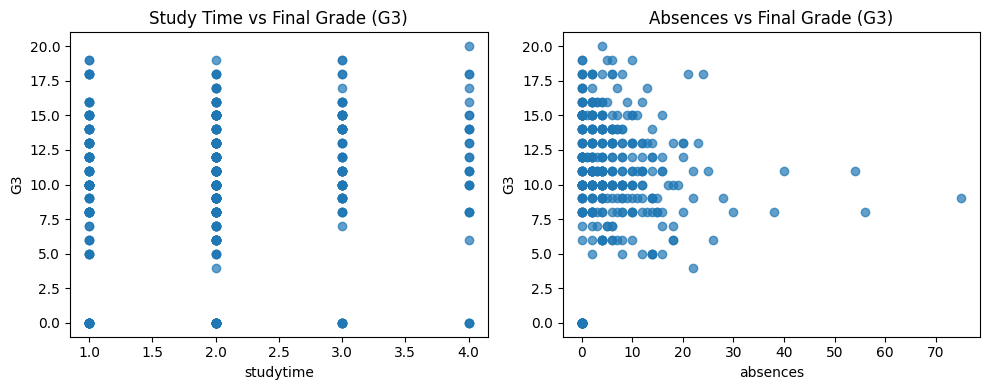

In [240]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(df["studytime"], df["G3"], alpha=0.7)
axes[0].set_title("Study Time vs Final Grade (G3)")
axes[0].set_xlabel("studytime")
axes[0].set_ylabel("G3")

axes[1].scatter(df["absences"], df["G3"], alpha=0.7)
axes[1].set_title("Absences vs Final Grade (G3)")
axes[1].set_xlabel("absences")
axes[1].set_ylabel("G3")

plt.tight_layout()
plt.show()

The histogram of G3 shows that most final grades are concentrated in the middle range, with relatively few extreme values, although some students have a grade of 0. The scatter plot of studytime against G3 suggests a possible positive association, since higher study time levels appear to include more higher grades, but the relationship is not strong. The scatter plot of absences against G3 suggests a possible negative association, as high grades seem less common when absences are larger, although the pattern is still fairly dispersed. Overall, these plots indicate that the predictors may contain useful information, but the relationships are not perfectly simple or linear.

## 3. Model Training

The data are first split into training and test sets before fitting any model.

In [241]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

### 3.1 Linear Regression

In [242]:
import warnings
warnings.filterwarnings("ignore")

lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
y_pred_lin = lin_model.predict(X_test)

mae_lin = mean_absolute_error(y_test, y_pred_lin)
rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))

print("Linear Regression")
print("MAE :", round(mae_lin, 3))
print("RMSE:", round(rmse_lin, 3))

Linear Regression
MAE : 3.395
RMSE: 4.196


### 3.2 k-NN Regressor

In [243]:
# Standard scaling for k-NN only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled test data shape:", X_test_scaled.shape)

knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)

mae_knn = mean_absolute_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))

print("k-NN Regressor")
print("MAE :", round(mae_knn, 3))
print("RMSE:", round(rmse_knn, 3))

Scaled training data shape: (316, 56)
Scaled test data shape: (79, 56)
k-NN Regressor
MAE : 3.754
RMSE: 4.621


### 3.3 Decision Tree Regressor

In [244]:
tree_model = DecisionTreeRegressor(max_depth=5, random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

mae_tree = mean_absolute_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))

print("Decision Tree Regressor")
print("MAE :", round(mae_tree, 3))
print("RMSE:", round(rmse_tree, 3))

Decision Tree Regressor
MAE : 3.536
RMSE: 4.621


## 4. Results and Comparison

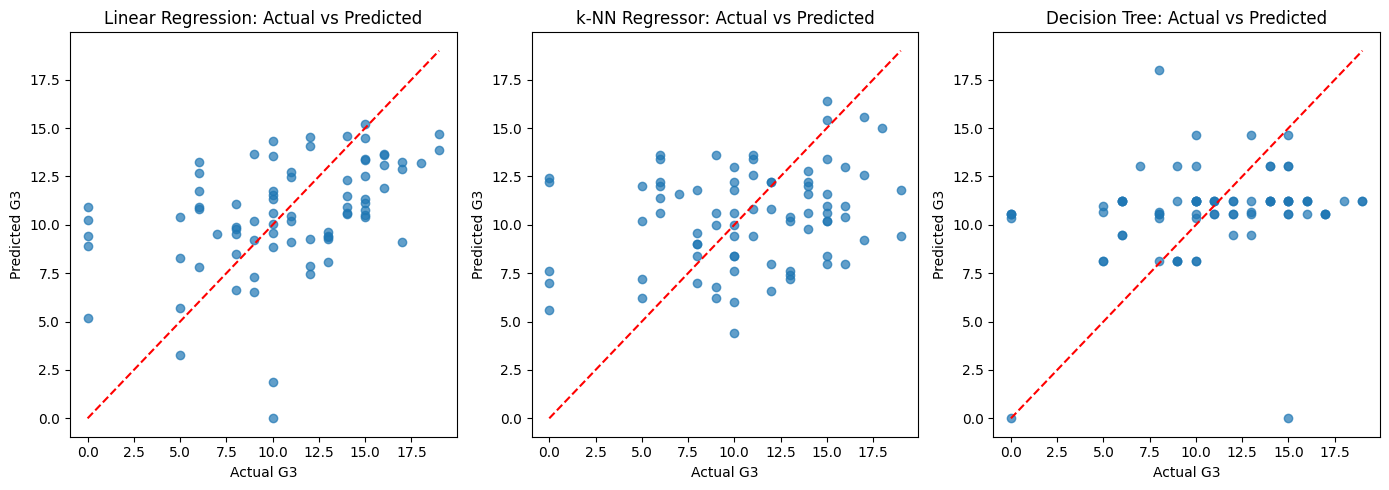

In [245]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Linear Regression
axes[0].scatter(y_test, y_pred_lin, alpha=0.7)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
axes[0].set_title("Linear Regression: Actual vs Predicted")
axes[0].set_xlabel("Actual G3")
axes[0].set_ylabel("Predicted G3")

# k-NN
axes[1].scatter(y_test, y_pred_knn, alpha=0.7)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
axes[1].set_title("k-NN Regressor: Actual vs Predicted")
axes[1].set_xlabel("Actual G3")
axes[1].set_ylabel("Predicted G3")

# Decision Tree
axes[2].scatter(y_test, y_pred_tree, alpha=0.7)
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
axes[2].set_title("Decision Tree: Actual vs Predicted")
axes[2].set_xlabel("Actual G3")
axes[2].set_ylabel("Predicted G3")

plt.tight_layout()
plt.show()

The three actual-versus-predicted plots compare how well each model predicts the final grade G3. Points closer to the dashed diagonal line indicate more accurate predictions. Overall, Linear Regression gives the closest predictions, while k-NN tends to shrink predictions towards the middle range and the Decision Tree produces more discrete prediction levels. All three models make larger errors for some low or zero grades, suggesting that these cases are harder to predict from the available features.

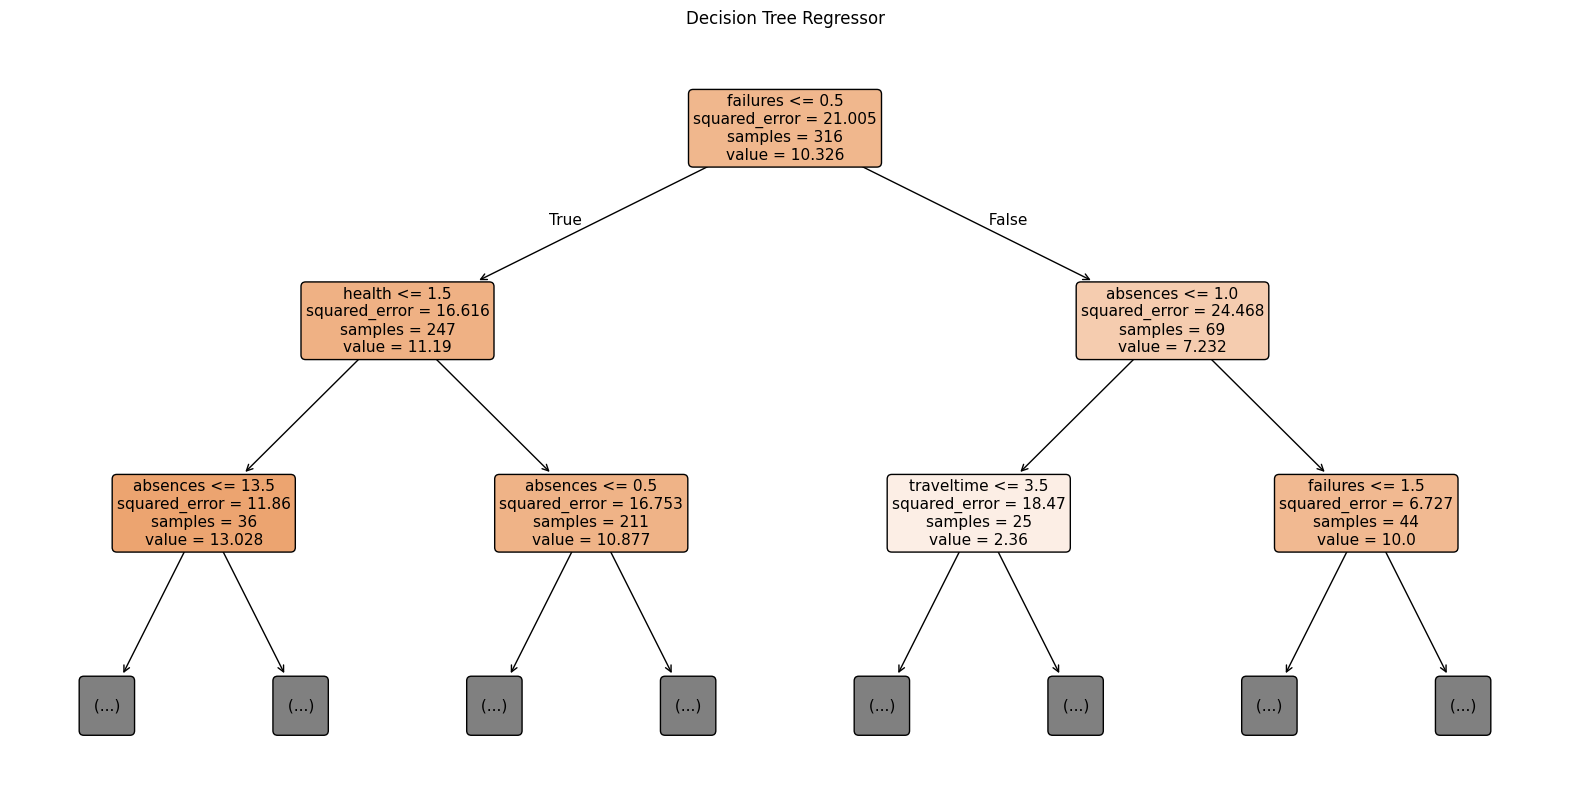

In [246]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(
    tree_model,
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    max_depth=2
)
plt.title("Decision Tree Regressor")
plt.show()

This tree shows that the model first splits students by previous failures, meaning this is an important predictor of G3. Students with no failures tend to have higher predicted grades, while students with previous failures are predicted lower. Later splits use variables such as health, absences and travel time.

In [247]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "k-NN Regressor", "Decision Tree Regressor"],
    "MAE": [mae_lin, mae_knn, mae_tree],
    "RMSE": [rmse_lin, rmse_knn, rmse_tree]
})

results

,Model,MAE,RMSE
0,Linear Regression,3.395261,4.195681
1,k-NN Regressor,3.754430,4.620538
2,Decision Tree Regressor,3.535835,4.621128


Linear Regression gives the best overall performance, with the lowest MAE (3.40) and RMSE (4.20). k-NN and Decision Tree perform slightly worse, with similar RMSE values around 4.62. The higher RMSE than MAE across all models suggests that some individual predictions have large errors, possibly including students with G3 = 0.

## 5. Conclusion

Among the three models, Linear Regression performed best (MAE = 3.40, 
RMSE = 4.20), suggesting that a global linear approach captures the 
overall pattern more effectively than k-NN and Decision Tree on this 
dataset. All models struggled with extreme grades, particularly G3 = 0, 
which are harder to predict from demographic features alone.